In [7]:
import os
import shutil

SOURCE_DIR = (
    "/kaggle/input/datasets/mohammadamanlou/"
    "frontier/frontiermem_llm_prototype_fixed"
)

WORK_DIR = "/kaggle/working/frontiermem_llm_prototype_fixed"

if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)

shutil.copytree(SOURCE_DIR, WORK_DIR)

print("Copied successfully.")
print("Source exists:", os.path.exists(SOURCE_DIR))
print("Work directory exists:", os.path.exists(WORK_DIR))

Copied successfully.
Source exists: True
Work directory exists: True


In [9]:
%cd /kaggle/working/frontiermem_llm_prototype_fixed

/kaggle/working/frontiermem_llm_prototype_fixed


In [10]:
!pwd
!find . -maxdepth 2 -type f | sort | head -60

/kaggle/working/frontiermem_llm_prototype_fixed
./data/frontier_suite_mini.csv
./frontiermem/baselines.py
./frontiermem/data.py
./frontiermem/evaluation.py
./frontiermem/hf_small_llm.py
./frontiermem/__init__.py
./frontiermem/memory.py
./frontiermem/tiny_lm.py
./frontiermem/visualization.py
./MANIFEST.txt
./notebooks/FrontierMem_Small_LLM_Prototype.ipynb
./pyproject.toml
./README.md
./requirements-hf.txt
./requirements.txt
./results/boundary_metrics_all_local.png
./results/boundary_metrics_rules.png
./results/boundary_metrics_tiny_lm.png
./results/error_rates_all_local.png
./results/error_rates_rules.png
./results/error_rates_tiny_lm.png
./results/example_rule_memories.json
./results/main_metrics_all_local.png
./results/main_metrics_rules.png
./results/main_metrics_tiny_lm.png
./results/metrics_all_local.csv
./results/metrics_rules_and_baselines.csv
./results/metrics_tiny_lm.csv
./results/rule_memory_extraction_metrics.csv
./RESULTS_SUMMARY.md
./results/test_predictions_rules_and_basel

In [11]:
!pip install -q -U \
    "transformers>=4.45,<5" \
    accelerate \
    safetensors \
    sentencepiece \
    huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 86.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.3 MB/s eta 0:00:00


In [12]:
import transformers
import accelerate
import torch

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Transformers: 4.57.6
Accelerate: 1.14.0
Torch: 2.10.0+cu128
CUDA: True


In [13]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode gold_memory_llm \
    --max-examples 2

tokenizer_config.json: 7.30kB [00:00, 22.3MB/s]
vocab.json: 2.78MB [00:00, 45.7MB/s]
merges.txt: 1.67MB [00:00, 120MB/s]
tokenizer.json: 7.03MB [00:00, 156MB/s]
config.json: 100%|█████████████████████████████| 660/660 [00:00<00:00, 5.66MB/s]
model.safetensors: 100%|███████████████████| 3.09G/3.09G [00:32<00:00, 95.9MB/s]
generation_config.json: 100%|██████████████████| 242/242 [00:00<00:00, 1.40MB/s]
[1/2] mode=gold_memory_llm family=writing_directness gold=APPLY
[2/2] mode=gold_memory_llm family=food_vegetarian gold=APPLY
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(

Metrics
                                 model  accuracy  balanced_accuracy  macro_f1  inside_accuracy  outside_accuracy  near_accuracy  overgeneralization_rate  unnecessary_clarification_rate  twin_exact

In [14]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode gold_memory_llm \
    --max-examples 72

[1/72] mode=gold_memory_llm family=writing_directness gold=APPLY
[2/72] mode=gold_memory_llm family=food_vegetarian gold=APPLY
[3/72] mode=gold_memory_llm family=food_quick_meals gold=CLARIFY
[4/72] mode=gold_memory_llm family=education_answer_only gold=APPLY
[5/72] mode=gold_memory_llm family=writing_formality gold=APPLY
[6/72] mode=gold_memory_llm family=education_detail gold=APPLY
[7/72] mode=gold_memory_llm family=education_detail gold=IGNORE
[8/72] mode=gold_memory_llm family=education_examples gold=IGNORE
[9/72] mode=gold_memory_llm family=travel_budget gold=APPLY
[10/72] mode=gold_memory_llm family=food_spiciness gold=APPLY
[11/72] mode=gold_memory_llm family=food_vegetarian gold=IGNORE
[12/72] mode=gold_memory_llm family=travel_budget gold=APPLY
[13/72] mode=gold_memory_llm family=food_spiciness gold=APPLY
[14/72] mode=gold_memory_llm family=writing_formality gold=APPLY
[15/72] mode=gold_memory_llm family=education_examples gold=APPLY
[16/72] mode=gold_memory_llm family=travel_

In [15]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode rule_memory_llm \
    --max-examples 72

[1/72] mode=rule_memory_llm family=writing_directness gold=APPLY
[2/72] mode=rule_memory_llm family=food_vegetarian gold=APPLY
[3/72] mode=rule_memory_llm family=food_quick_meals gold=CLARIFY
[4/72] mode=rule_memory_llm family=education_answer_only gold=APPLY
[5/72] mode=rule_memory_llm family=writing_formality gold=APPLY
[6/72] mode=rule_memory_llm family=education_detail gold=APPLY
[7/72] mode=rule_memory_llm family=education_detail gold=IGNORE
[8/72] mode=rule_memory_llm family=education_examples gold=IGNORE
[9/72] mode=rule_memory_llm family=travel_budget gold=APPLY
[10/72] mode=rule_memory_llm family=food_spiciness gold=APPLY
[11/72] mode=rule_memory_llm family=food_vegetarian gold=IGNORE
[12/72] mode=rule_memory_llm family=travel_budget gold=APPLY
[13/72] mode=rule_memory_llm family=food_spiciness gold=APPLY
[14/72] mode=rule_memory_llm family=writing_formality gold=APPLY
[15/72] mode=rule_memory_llm family=education_examples gold=APPLY
[16/72] mode=rule_memory_llm family=travel_

In [16]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode llm_memory_rule \
    --max-examples 72

[1/72] mode=llm_memory_rule family=writing_directness gold=APPLY
[2/72] mode=llm_memory_rule family=food_vegetarian gold=APPLY
[3/72] mode=llm_memory_rule family=food_quick_meals gold=CLARIFY
[4/72] mode=llm_memory_rule family=education_answer_only gold=APPLY
[5/72] mode=llm_memory_rule family=writing_formality gold=APPLY
[6/72] mode=llm_memory_rule family=education_detail gold=APPLY
[7/72] mode=llm_memory_rule family=education_detail gold=IGNORE
[8/72] mode=llm_memory_rule family=education_examples gold=IGNORE
[9/72] mode=llm_memory_rule family=travel_budget gold=APPLY
[10/72] mode=llm_memory_rule family=food_spiciness gold=APPLY
[11/72] mode=llm_memory_rule family=food_vegetarian gold=IGNORE
[12/72] mode=llm_memory_rule family=travel_budget gold=APPLY
[13/72] mode=llm_memory_rule family=food_spiciness gold=APPLY
[14/72] mode=llm_memory_rule family=writing_formality gold=APPLY
[15/72] mode=llm_memory_rule family=education_examples gold=APPLY
[16/72] mode=llm_memory_rule family=travel_

In [17]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode full_llm \
    --max-examples 24

[1/24] mode=full_llm family=writing_directness gold=APPLY
[2/24] mode=full_llm family=food_vegetarian gold=APPLY
[3/24] mode=full_llm family=food_quick_meals gold=CLARIFY
[4/24] mode=full_llm family=education_answer_only gold=APPLY
[5/24] mode=full_llm family=writing_formality gold=APPLY
[6/24] mode=full_llm family=education_detail gold=APPLY
[7/24] mode=full_llm family=education_detail gold=IGNORE
[8/24] mode=full_llm family=education_examples gold=IGNORE
[9/24] mode=full_llm family=travel_budget gold=APPLY
[10/24] mode=full_llm family=food_spiciness gold=APPLY
[11/24] mode=full_llm family=food_vegetarian gold=IGNORE
[12/24] mode=full_llm family=education_examples gold=APPLY
[13/24] mode=full_llm family=travel_proximity gold=APPLY
[14/24] mode=full_llm family=food_quick_meals gold=APPLY
[15/24] mode=full_llm family=food_vegetarian gold=CLARIFY
[16/24] mode=full_llm family=travel_comfort gold=APPLY
[17/24] mode=full_llm family=education_answer_only gold=IGNORE
[18/24] mode=full_llm fam

In [18]:
import glob
import os
import pandas as pd
from IPython.display import display

metric_files = glob.glob(
    "/kaggle/working/frontiermem_llm_prototype_fixed/"
    "results/metrics_Qwen*.csv"
)

print("Found metric files:")

for path in metric_files:
    print(os.path.basename(path))

all_metrics = pd.concat(
    [pd.read_csv(path) for path in metric_files],
    ignore_index=True,
)

display(all_metrics)

Found metric files:
metrics_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv
metrics_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv
metrics_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv
metrics_Qwen2_5-1_5B-Instruct_full_llm.csv


,model,accuracy,balanced_accuracy,macro_f1,inside_accuracy,outside_accuracy,near_accuracy,overgeneralization_rate,unnecessary_clarification_rate,twin_exact_match,twin_discrimination_accuracy,different_gold_twin_pairs,n_examples
0,Qwen2.5-1.5B-Instruct::llm_memory_rule,0.666667,0.666667,0.653465,0.833333,0.375000,0.791667,0.125000,0.333333,0.333333,0.666667,3,72
1,Qwen2.5-1.5B-Instruct::rule_memory_llm,0.708333,0.708333,0.684453,1.000000,0.333333,0.791667,0.541667,0.062500,1.000000,1.000000,3,72
2,Qwen2.5-1.5B-Instruct::gold_memory_llm,0.625000,0.625000,0.600402,1.000000,0.291667,0.583333,0.583333,0.062500,0.666667,0.666667,3,72
3,Qwen2.5-1.5B-Instruct::full_llm,0.291667,0.333333,0.150538,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,0,24


In [19]:
columns = [
    col for col in [
        "model",
        "mode",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "inside_accuracy",
        "outside_accuracy",
        "near_accuracy",
        "overgeneralization_rate",
        "unnecessary_clarification_rate",
        "n_examples",
    ]
    if col in all_metrics.columns
]

display(
    all_metrics[columns]
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

,model,accuracy,balanced_accuracy,macro_f1,inside_accuracy,outside_accuracy,near_accuracy,overgeneralization_rate,unnecessary_clarification_rate,n_examples
0,Qwen2.5-1.5B-Instruct::rule_memory_llm,0.708333,0.708333,0.684453,1.000000,0.333333,0.791667,0.541667,0.062500,72
1,Qwen2.5-1.5B-Instruct::llm_memory_rule,0.666667,0.666667,0.653465,0.833333,0.375000,0.791667,0.125000,0.333333,72
2,Qwen2.5-1.5B-Instruct::gold_memory_llm,0.625000,0.625000,0.600402,1.000000,0.291667,0.583333,0.583333,0.062500,72
3,Qwen2.5-1.5B-Instruct::full_llm,0.291667,0.333333,0.150538,0.000000,1.000000,0.000000,0.000000,0.000000,24


In [20]:
prediction_files = glob.glob(
    "/kaggle/working/frontiermem_llm_prototype_fixed/"
    "results/predictions_Qwen*.csv"
)

for path in prediction_files:
    df = pd.read_csv(path)

    print("\n" + "=" * 90)
    print(os.path.basename(path))

    print("\nGold labels:")
    print(df["action"].value_counts().to_dict())

    print("\nModel predictions:")
    print(df["prediction"].value_counts().to_dict())


predictions_Qwen2_5-1_5B-Instruct_full_llm.csv

Gold labels:
{'APPLY': 11, 'IGNORE': 7, 'CLARIFY': 6}

Model predictions:
{'IGNORE': 24}

predictions_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv

Gold labels:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Model predictions:
{'APPLY': 48, 'CLARIFY': 17, 'IGNORE': 7}

predictions_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv

Gold labels:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Model predictions:
{'CLARIFY': 35, 'APPLY': 25, 'IGNORE': 12}

predictions_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv

Gold labels:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Model predictions:
{'APPLY': 42, 'CLARIFY': 22, 'IGNORE': 8}


In [21]:
for path in prediction_files:
    df = pd.read_csv(path)

    print("\n" + os.path.basename(path))

    display(
        pd.crosstab(
            df["action"],
            df["prediction"],
            rownames=["Gold"],
            colnames=["Prediction"],
            margins=True,
        )
    )


predictions_Qwen2_5-1_5B-Instruct_full_llm.csv


Prediction,IGNORE,All
Gold,,
APPLY,11,11
CLARIFY,6,6
IGNORE,7,7
All,24,24



predictions_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv


Prediction,APPLY,CLARIFY,IGNORE,All
Gold,,,,
APPLY,24,0,0,24
CLARIFY,10,14,0,24
IGNORE,14,3,7,24
All,48,17,7,72



predictions_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv


Prediction,APPLY,CLARIFY,IGNORE,All
Gold,,,,
APPLY,20,4,0,24
CLARIFY,2,19,3,24
IGNORE,3,12,9,24
All,25,35,12,72



predictions_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv


Prediction,APPLY,CLARIFY,IGNORE,All
Gold,,,,
APPLY,24,0,0,24
CLARIFY,5,19,0,24
IGNORE,13,3,8,24
All,42,22,8,72


In [22]:
df = pd.read_csv(prediction_files[0])

selected_columns = [
    col for col in [
        "family",
        "profile_variant",
        "query",
        "action",
        "prediction",
        "response",
        "decision_reason",
        "memory_parse_mode",
        "decision_parse_mode",
    ]
    if col in df.columns
]

display(df[selected_columns].head(10))

,family,profile_variant,query,action,prediction,memory_parse_mode,decision_parse_mode
0,writing_directness,stable,Write a compassionate message to someone facin...,APPLY,IGNORE,json,json
1,food_vegetarian,stable,"Plan dinner for my sister, who still follows a...",APPLY,IGNORE,json,json
2,food_quick_meals,scoped,I have not said whether I am still busy or fin...,CLARIFY,IGNORE,json,json
3,education_answer_only,stable,I am unsure whether I want speed or explanatio...,APPLY,IGNORE,json,json
4,writing_formality,stable,Help me write to a potential employer.,APPLY,IGNORE,json,json
5,education_detail,scoped,"I am new to this subject, so build the explana...",APPLY,IGNORE,json,json
6,education_detail,scoped,I only need a quick correctness check on a fam...,IGNORE,IGNORE,json,json
7,education_examples,scoped,"I need a compact reference entry, not a worked...",IGNORE,IGNORE,json,json
8,travel_budget,stable,Find lodging for a trip with a firm reimbursem...,APPLY,IGNORE,json,json
9,food_spiciness,stable,I remain on the medicine and cannot handle str...,APPLY,IGNORE,json,json


In [23]:
import shutil

output_zip = "/kaggle/working/FrontierMem_1_5B_Results"

shutil.make_archive(
    output_zip,
    "zip",
    root_dir="/kaggle/working/frontiermem_llm_prototype_fixed",
    base_dir="results",
)

print("Created:", output_zip + ".zip")

Created: /kaggle/working/FrontierMem_1_5B_Results.zip


In [24]:
from IPython.display import FileLink, display

display(
    FileLink(
        "/kaggle/working/FrontierMem_1_5B_Results.zip"
    )
)

/kaggle/working/FrontierMem_1_5B_Results.zip

In [25]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-1.5B-Instruct \
    --mode full_llm \
    --max-examples 72

[1/72] mode=full_llm family=writing_directness gold=APPLY
[2/72] mode=full_llm family=food_vegetarian gold=APPLY
[3/72] mode=full_llm family=food_quick_meals gold=CLARIFY
[4/72] mode=full_llm family=education_answer_only gold=APPLY
[5/72] mode=full_llm family=writing_formality gold=APPLY
[6/72] mode=full_llm family=education_detail gold=APPLY
[7/72] mode=full_llm family=education_detail gold=IGNORE
[8/72] mode=full_llm family=education_examples gold=IGNORE
[9/72] mode=full_llm family=travel_budget gold=APPLY
[10/72] mode=full_llm family=food_spiciness gold=APPLY
[11/72] mode=full_llm family=food_vegetarian gold=IGNORE
[12/72] mode=full_llm family=travel_budget gold=APPLY
[13/72] mode=full_llm family=food_spiciness gold=APPLY
[14/72] mode=full_llm family=writing_formality gold=APPLY
[15/72] mode=full_llm family=education_examples gold=APPLY
[16/72] mode=full_llm family=travel_proximity gold=APPLY
[17/72] mode=full_llm family=food_quick_meals gold=APPLY
[18/72] mode=full_llm family=food_

In [26]:
from pathlib import Path
import os
import pandas as pd
from IPython.display import display

PROJECT_DIR = Path(
    "/kaggle/working/frontiermem_llm_prototype_fixed"
)
RESULTS_DIR = PROJECT_DIR / "results"

MODEL_SLUG = "Qwen2_5-1_5B-Instruct"

MODES = [
    "gold_memory_llm",
    "rule_memory_llm",
    "llm_memory_rule",
    "full_llm",
]

print("Project exists:", PROJECT_DIR.exists())
print("Results exists:", RESULTS_DIR.exists())

for path in sorted(RESULTS_DIR.glob("*Qwen2_5-1_5B-Instruct*")):
    print(
        path.name,
        "-",
        round(path.stat().st_size / 1024, 2),
        "KB",
    )

Project exists: True
Results exists: True
extraction_Qwen2_5-1_5B-Instruct_full_llm.csv - 0.17 KB
extraction_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv - 0.17 KB
metrics_Qwen2_5-1_5B-Instruct_full_llm.csv - 0.34 KB
metrics_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv - 0.41 KB
metrics_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv - 0.42 KB
metrics_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv - 0.39 KB
predictions_Qwen2_5-1_5B-Instruct_full_llm.csv - 189.1 KB
predictions_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv - 133.19 KB
predictions_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv - 168.65 KB
predictions_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv - 133.37 KB


In [27]:
missing = []

for mode in MODES:
    pred_path = (
        RESULTS_DIR
        / f"predictions_{MODEL_SLUG}_{mode}.csv"
    )
    metric_path = (
        RESULTS_DIR
        / f"metrics_{MODEL_SLUG}_{mode}.csv"
    )

    if not pred_path.exists():
        missing.append(str(pred_path.name))

    if not metric_path.exists():
        missing.append(str(metric_path.name))

if missing:
    print("Missing files:")
    for name in missing:
        print("-", name)
else:
    print("All four experiments are available.")

All four experiments are available.


In [28]:
%cd /kaggle/working/frontiermem_llm_prototype_fixed

/kaggle/working/frontiermem_llm_prototype_fixed


In [29]:
%cd /kaggle/working/frontiermem_llm_prototype_fixed

/kaggle/working/frontiermem_llm_prototype_fixed


In [30]:
metric_frames = []

for mode in MODES:
    path = RESULTS_DIR / f"metrics_{MODEL_SLUG}_{mode}.csv"

    if path.exists():
        part = pd.read_csv(path)
        part.insert(0, "mode", mode)
        metric_frames.append(part)

all_metrics = pd.concat(
    metric_frames,
    ignore_index=True,
)

main_columns = [
    "mode",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "inside_accuracy",
    "outside_accuracy",
    "near_accuracy",
    "overgeneralization_rate",
    "unnecessary_clarification_rate",
    "twin_exact_match",
    "twin_discrimination_accuracy",
    "n_examples",
]

main_columns = [
    col for col in main_columns
    if col in all_metrics.columns
]

metrics_summary = all_metrics[main_columns].copy()

display(
    metrics_summary
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

,mode,accuracy,balanced_accuracy,macro_f1,inside_accuracy,outside_accuracy,near_accuracy,overgeneralization_rate,unnecessary_clarification_rate,twin_exact_match,twin_discrimination_accuracy,n_examples
0,rule_memory_llm,0.708333,0.708333,0.684453,1.000000,0.333333,0.791667,0.541667,0.062500,1.000000,1.000000,72
1,llm_memory_rule,0.666667,0.666667,0.653465,0.833333,0.375000,0.791667,0.125000,0.333333,0.333333,0.666667,72
2,gold_memory_llm,0.625000,0.625000,0.600402,1.000000,0.291667,0.583333,0.583333,0.062500,0.666667,0.666667,72
3,full_llm,0.333333,0.333333,0.166667,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72


In [31]:
percentage_columns = [
    col for col in metrics_summary.columns
    if col not in ["mode", "n_examples"]
]

metrics_percentage = metrics_summary.copy()

for col in percentage_columns:
    metrics_percentage[col] = (
        metrics_percentage[col] * 100
    ).round(2)

display(
    metrics_percentage
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

,mode,accuracy,balanced_accuracy,macro_f1,inside_accuracy,outside_accuracy,near_accuracy,overgeneralization_rate,unnecessary_clarification_rate,twin_exact_match,twin_discrimination_accuracy,n_examples
0,rule_memory_llm,70.83,70.83,68.45,100.00,33.33,79.17,54.17,6.25,100.00,100.00,72
1,llm_memory_rule,66.67,66.67,65.35,83.33,37.50,79.17,12.50,33.33,33.33,66.67,72
2,gold_memory_llm,62.50,62.50,60.04,100.00,29.17,58.33,58.33,6.25,66.67,66.67,72
3,full_llm,33.33,33.33,16.67,0.00,100.00,0.00,0.00,0.00,0.00,0.00,72


In [32]:
summary_path = (
    RESULTS_DIR
    / "qwen_1_5b_ablation_summary.csv"
)

metrics_summary.to_csv(
    summary_path,
    index=False,
)

print("Saved:", summary_path)

Saved: /kaggle/working/frontiermem_llm_prototype_fixed/results/qwen_1_5b_ablation_summary.csv


In [33]:
LABELS = ["APPLY", "IGNORE", "CLARIFY"]

distribution_rows = []

for mode in MODES:
    path = (
        RESULTS_DIR
        / f"predictions_{MODEL_SLUG}_{mode}.csv"
    )

    if not path.exists():
        continue

    df = pd.read_csv(path)

    print("\n" + "=" * 80)
    print("Mode:", mode)

    print("\nGold distribution:")
    print(df["action"].value_counts().to_dict())

    print("\nPrediction distribution:")
    print(df["prediction"].value_counts().to_dict())

    for label in LABELS:
        distribution_rows.append({
            "mode": mode,
            "label": label,
            "gold_count": int(
                (df["action"] == label).sum()
            ),
            "prediction_count": int(
                (df["prediction"] == label).sum()
            ),
        })

distribution_df = pd.DataFrame(distribution_rows)

display(distribution_df)


Mode: gold_memory_llm

Gold distribution:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Prediction distribution:
{'APPLY': 48, 'CLARIFY': 17, 'IGNORE': 7}

Mode: rule_memory_llm

Gold distribution:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Prediction distribution:
{'APPLY': 42, 'CLARIFY': 22, 'IGNORE': 8}

Mode: llm_memory_rule

Gold distribution:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Prediction distribution:
{'CLARIFY': 35, 'APPLY': 25, 'IGNORE': 12}

Mode: full_llm

Gold distribution:
{'APPLY': 24, 'CLARIFY': 24, 'IGNORE': 24}

Prediction distribution:
{'IGNORE': 72}


,mode,label,gold_count,prediction_count
0,gold_memory_llm,APPLY,24,48
1,gold_memory_llm,IGNORE,24,7
2,gold_memory_llm,CLARIFY,24,17
3,rule_memory_llm,APPLY,24,42
4,rule_memory_llm,IGNORE,24,8
5,rule_memory_llm,CLARIFY,24,22
6,llm_memory_rule,APPLY,24,25
7,llm_memory_rule,IGNORE,24,12
8,llm_memory_rule,CLARIFY,24,35
9,full_llm,APPLY,24,0


In [34]:
distribution_df.to_csv(
    RESULTS_DIR
    / "qwen_1_5b_prediction_distribution.csv",
    index=False,
)

In [35]:
confusion_matrices = {}

for mode in MODES:
    path = (
        RESULTS_DIR
        / f"predictions_{MODEL_SLUG}_{mode}.csv"
    )

    if not path.exists():
        continue

    df = pd.read_csv(path)

    cm = pd.crosstab(
        df["action"],
        df["prediction"],
        rownames=["Gold"],
        colnames=["Prediction"],
    )

    cm = cm.reindex(
        index=LABELS,
        columns=LABELS,
        fill_value=0,
    )

    confusion_matrices[mode] = cm

    print("\n" + "=" * 80)
    print("Confusion Matrix:", mode)
    display(cm)

    cm.to_csv(
        RESULTS_DIR
        / f"confusion_{MODEL_SLUG}_{mode}.csv"
    )


Confusion Matrix: gold_memory_llm


Prediction,APPLY,IGNORE,CLARIFY
Gold,,,
APPLY,24,0,0
IGNORE,14,7,3
CLARIFY,10,0,14



Confusion Matrix: rule_memory_llm


Prediction,APPLY,IGNORE,CLARIFY
Gold,,,
APPLY,24,0,0
IGNORE,13,8,3
CLARIFY,5,0,19



Confusion Matrix: llm_memory_rule


Prediction,APPLY,IGNORE,CLARIFY
Gold,,,
APPLY,20,0,4
IGNORE,3,9,12
CLARIFY,2,3,19



Confusion Matrix: full_llm


Prediction,APPLY,IGNORE,CLARIFY
Gold,,,
APPLY,0,24,0
IGNORE,0,24,0
CLARIFY,0,24,0


In [36]:
extraction_frames = []

for mode in ["llm_memory_rule", "full_llm"]:
    path = (
        RESULTS_DIR
        / f"extraction_{MODEL_SLUG}_{mode}.csv"
    )

    if path.exists():
        part = pd.read_csv(path)
        part["mode"] = mode
        extraction_frames.append(part)

if extraction_frames:
    extraction_all = pd.concat(
        extraction_frames,
        ignore_index=True,
    )

    extraction_pivot = extraction_all.pivot(
        index="metric",
        columns="mode",
        values="score",
    )

    display(extraction_pivot)

    extraction_pivot.to_csv(
        RESULTS_DIR
        / "qwen_1_5b_extraction_summary.csv"
    )
else:
    print("No extraction files were found.")

mode,full_llm,llm_memory_rule
metric,,
family_correct,0.375000,0.375000
information_type_correct,0.111111,0.111111
owner_correct,0.000000,0.000000
profile_variant_correct,0.902778,0.902778
temporal_correct,0.847222,0.847222


In [37]:
display(
    (extraction_pivot * 100).round(2)
)

mode,full_llm,llm_memory_rule
metric,,
family_correct,37.50,37.50
information_type_correct,11.11,11.11
owner_correct,0.00,0.00
profile_variant_correct,90.28,90.28
temporal_correct,84.72,84.72


In [38]:
parser_rows = []

for mode in MODES:
    path = (
        RESULTS_DIR
        / f"predictions_{MODEL_SLUG}_{mode}.csv"
    )

    if not path.exists():
        continue

    df = pd.read_csv(path)

    for column in [
        "memory_parse_mode",
        "decision_parse_mode",
    ]:
        if column not in df.columns:
            continue

        counts = (
            df[column]
            .fillna("missing")
            .astype(str)
            .value_counts()
        )

        for parse_mode, count in counts.items():
            parser_rows.append({
                "experiment": mode,
                "parser_stage": column,
                "parse_mode": parse_mode,
                "count": int(count),
            })

parser_summary = pd.DataFrame(parser_rows)

display(parser_summary)

,experiment,parser_stage,parse_mode,count
0,gold_memory_llm,memory_parse_mode,gold,72
1,gold_memory_llm,decision_parse_mode,llm_label,72
2,rule_memory_llm,memory_parse_mode,rule,72
3,rule_memory_llm,decision_parse_mode,llm_label,72
4,llm_memory_rule,memory_parse_mode,json,72
5,llm_memory_rule,decision_parse_mode,rule_policy,72
6,full_llm,memory_parse_mode,json,72
7,full_llm,decision_parse_mode,json,72


In [39]:
parser_summary.to_csv(
    RESULTS_DIR
    / "qwen_1_5b_parser_summary.csv",
    index=False,
)

In [40]:
fallback_rows = []

for mode in MODES:
    path = (
        RESULTS_DIR
        / f"predictions_{MODEL_SLUG}_{mode}.csv"
    )

    if not path.exists():
        continue

    df = pd.read_csv(path)

    for column in [
        "memory_parse_mode",
        "decision_parse_mode",
    ]:
        if column not in df.columns:
            continue

        fallback_count = (
            df[column]
            .fillna("")
            .astype(str)
            .str.contains(
                "fallback",
                case=False,
                regex=False,
            )
            .sum()
        )

        fallback_rows.append({
            "mode": mode,
            "stage": column,
            "fallback_count": int(fallback_count),
            "total": len(df),
        })

fallback_summary = pd.DataFrame(fallback_rows)

display(fallback_summary)

,mode,stage,fallback_count,total
0,gold_memory_llm,memory_parse_mode,0,72
1,gold_memory_llm,decision_parse_mode,0,72
2,rule_memory_llm,memory_parse_mode,0,72
3,rule_memory_llm,decision_parse_mode,0,72
4,llm_memory_rule,memory_parse_mode,0,72
5,llm_memory_rule,decision_parse_mode,0,72
6,full_llm,memory_parse_mode,0,72
7,full_llm,decision_parse_mode,0,72


In [41]:
full_path = (
    RESULTS_DIR
    / f"predictions_{MODEL_SLUG}_full_llm.csv"
)

full_df = pd.read_csv(full_path)

full_df["correct"] = (
    full_df["action"] == full_df["prediction"]
)

print("Examples:", len(full_df))
print("Correct:", int(full_df["correct"].sum()))
print("Incorrect:", int((~full_df["correct"]).sum()))
print("Accuracy:", round(full_df["correct"].mean(), 4))

Examples: 72
Correct: 24
Incorrect: 48
Accuracy: 0.3333


In [42]:
zone_analysis = (
    full_df
    .groupby("zone", dropna=False)
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
)

display(zone_analysis)

zone_analysis.to_csv(
    RESULTS_DIR / "full_llm_by_zone.csv",
    index=False,
)

,zone,n,correct,accuracy
0,inside,24,0,0.0
1,near,24,0,0.0
2,outside,24,24,1.0


In [43]:
profile_analysis = (
    full_df
    .groupby("profile_variant", dropna=False)
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
)

display(profile_analysis)

profile_analysis.to_csv(
    RESULTS_DIR / "full_llm_by_profile_variant.csv",
    index=False,
)

,profile_variant,n,correct,accuracy
0,scoped,53,24,0.45283
1,stable,19,0,0.00000


In [44]:
domain_analysis = (
    full_df
    .groupby("domain", dropna=False)
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
    .sort_values(
        "accuracy",
        ascending=False,
    )
)

display(domain_analysis)

domain_analysis.to_csv(
    RESULTS_DIR / "full_llm_by_domain.csv",
    index=False,
)

,domain,n,correct,accuracy
0,education,18,6,0.333333
1,food,18,6,0.333333
2,travel,18,6,0.333333
3,writing,18,6,0.333333


In [45]:
domain_analysis = (
    full_df
    .groupby("domain", dropna=False)
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
    .sort_values(
        "accuracy",
        ascending=False,
    )
)

display(domain_analysis)

domain_analysis.to_csv(
    RESULTS_DIR / "full_llm_by_domain.csv",
    index=False,
)

,domain,n,correct,accuracy
0,education,18,6,0.333333
1,food,18,6,0.333333
2,travel,18,6,0.333333
3,writing,18,6,0.333333


In [46]:
query_kind_analysis = (
    full_df
    .groupby("query_kind", dropna=False)
    .agg(
        n=("correct", "size"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
)

display(query_kind_analysis)

query_kind_analysis.to_csv(
    RESULTS_DIR / "full_llm_by_query_kind.csv",
    index=False,
)

,query_kind,n,correct,accuracy
0,inside,13,0,0.000000
1,near,30,0,0.000000
2,outside,29,24,0.827586


In [47]:
error_columns = [
    "example_id",
    "family",
    "domain",
    "profile_variant",
    "zone",
    "query_kind",
    "query",
    "action",
    "prediction",
    "pred_relation",
    "decision_confidence",
    "pred_family",
    "pred_profile_variant",
    "pred_owner",
    "pred_information_type",
    "pred_temporal_validity",
    "memory_parse_mode",
    "decision_parse_mode",
    "structured_memory",
    "decision_raw_output",
]

error_columns = [
    col for col in error_columns
    if col in full_df.columns
]

full_errors = full_df.loc[
    ~full_df["correct"],
    error_columns,
].copy()

print("Number of errors:", len(full_errors))

display(full_errors.head(20))

Number of errors: 48


,example_id,family,domain,profile_variant,zone,query_kind,query,action,prediction,pred_relation,decision_confidence,pred_family,pred_profile_variant,pred_owner,pred_information_type,pred_temporal_validity,memory_parse_mode,decision_parse_mode,structured_memory,decision_raw_output
0,writing_directness-test-004-outside-stable,writing_directness,writing,stable,inside,outside,Write a compassionate message to someone facin...,APPLY,IGNORE,mismatch,0.0,writing_directness,stable,session_history,persistent,persistent,json,json,"{""preference"": ""write_directness"", ""family"": ""...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
1,food_vegetarian-test-005-inside-stable,food_vegetarian,food,stable,inside,inside,"Plan dinner for my sister, who still follows a...",APPLY,IGNORE,mismatch,0.0,food_vegetarian,stable,me,persistent,persistent,json,json,"{""preference"": ""food_vegetarian"", ""family"": ""f...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
2,food_quick_meals-test-001-near-scoped,food_quick_meals,food,scoped,near,near,I have not said whether I am still busy or fin...,CLARIFY,IGNORE,unknown,0.0,writing_directness,scoped,session_3,temporary_constraint,context-dependent,json,json,"{""preference"": ""write_directness"", ""family"": ""...","{""action"":""IGNORE"",""relation"":""unknown"",""confi..."
3,education_answer_only-test-015-near-stable,education_answer_only,education,stable,inside,near,I am unsure whether I want speed or explanatio...,APPLY,IGNORE,unknown,0.0,writing_conciseness,stable,writing_directness,temporary_constraint,persistent,json,json,"{""preference"": ""education_answer_only"", ""famil...","{""action"":""IGNORE"",""relation"":""unknown"",""confi..."
4,writing_formality-test-014-inside-stable,writing_formality,writing,stable,inside,inside,Help me write to a potential employer.,APPLY,IGNORE,unknown,0.0,writing_formality,stable,none,none,persistent,json,json,"{""preference"": ""write_formality"", ""family"": ""w...","{""action"":""IGNORE"",""relation"":""unknown"",""confi..."
5,education_detail-test-003-inside-scoped,education_detail,education,scoped,inside,inside,"I am new to this subject, so build the explana...",APPLY,IGNORE,unknown,0.0,writing_conciseness,scoped,session_6,temporary_constraint,context-dependent,json,json,"{""preference"": ""education_answer_only"", ""famil...","{""action"":""IGNORE"",""relation"":""unknown"",""confi..."
8,travel_budget-test-007-inside-stable,travel_budget,travel,stable,inside,inside,Find lodging for a trip with a firm reimbursem...,APPLY,IGNORE,mismatch,0.0,travel_comfort,stable,session_history,persistent,persistent,json,json,"{""preference"": ""travel_budget"", ""family"": ""tra...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
9,food_spiciness-test-011-inside-stable,food_spiciness,food,stable,inside,inside,I remain on the medicine and cannot handle str...,APPLY,IGNORE,mismatch,0.0,food_spiciness,stable,NaN,persistent,persistent,json,json,"{""preference"": ""food_spiciness"", ""family"": ""fo...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
11,travel_budget-test-003-outside-stable,travel_budget,travel,stable,inside,outside,The organization is paying and there is no spe...,APPLY,IGNORE,mismatch,0.0,travel_comfort,scoped,session_5,temporary_constraint,context-dependent,json,json,"{""preference"": ""travel_budget"", ""family"": ""tra...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
12,food_spiciness-test-007-outside-stable,food_spiciness,food,stable,inside,outside,The medication is finished and the sensitivity...,APPLY,IGNORE,mismatch,0.0,travel_comfort,stable,NaN,temporary_constraint,context-dependent,json,json,"{""preference"": ""food_spiciness"", ""family"": ""tr...","{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."


In [49]:
full_errors.to_csv(
    RESULTS_DIR / "full_llm_errors.csv",
    index=False,
)

In [50]:
correct_columns = [
    "example_id",
    "family",
    "profile_variant",
    "zone",
    "query",
    "action",
    "prediction",
    "structured_memory",
    "generated_response",
]

correct_columns = [
    col for col in correct_columns
    if col in full_df.columns
]

correct_examples = full_df.loc[
    full_df["correct"],
    correct_columns,
].head(12)

display(correct_examples)

correct_examples.to_csv(
    RESULTS_DIR / "full_llm_correct_examples.csv",
    index=False,
)

,example_id,family,profile_variant,zone,query,action,prediction,structured_memory,generated_response
6,education_detail-test-014-outside-scoped,education_detail,scoped,outside,I only need a quick correctness check on a fam...,IGNORE,IGNORE,"{""preference"": ""education_answer_only"", ""famil...",NaN
7,education_examples-test-014-outside-scoped,education_examples,scoped,outside,"I need a compact reference entry, not a worked...",IGNORE,IGNORE,"{""preference"": ""education_examples"", ""family"":...",The query specifies that you need a compact re...
10,food_vegetarian-test-001-outside-scoped,food_vegetarian,scoped,outside,"This meal is solely for me, and I have no meat...",IGNORE,IGNORE,"{""preference"": ""food_vegetarian"", ""family"": ""f...",The query indicates that you have no meat rest...
21,education_answer_only-test-010-outside-scoped,education_answer_only,scoped,outside,Help me learn from this error with a full expl...,IGNORE,IGNORE,"{""preference"": ""answer_only"", ""family"": ""writi...",The information provided does not specify whet...
25,education_answer_only-test-008-outside-scoped,education_answer_only,scoped,outside,I am no longer timing myself; show me the reas...,IGNORE,IGNORE,"{""preference"": ""write_directness"", ""family"": ""...",The information provided does not directly rel...
27,writing_directness-test-013-outside-scoped,writing_directness,scoped,outside,Help me apologize after an emotional argument.,IGNORE,IGNORE,"{""preference"": ""write_directness"", ""family"": ""...",NaN
28,writing_directness-test-004-outside-scoped,writing_directness,scoped,outside,Write a compassionate message to someone facin...,IGNORE,IGNORE,"{""preference"": ""write_directly"", ""family"": ""wr...",The current query asks for a compassionate mes...
29,food_vegetarian-test-014-outside-scoped,food_vegetarian,scoped,outside,"This meal is solely for me, and I have no meat...",IGNORE,IGNORE,"{""preference"": ""food_vegetarian"", ""family"": ""f...",The query specifies that the meal is solely fo...
35,writing_formality-test-004-outside-scoped,writing_formality,scoped,outside,Make this sound natural for a group chat with ...,IGNORE,IGNORE,"{""preference"": ""write_formality"", ""family"": ""w...",The current query does not provide enough info...
37,writing_conciseness-test-006-outside-scoped,writing_conciseness,scoped,outside,"I want to understand this deeply, so explain e...",IGNORE,IGNORE,"{""preference"": ""write_directness"", ""family"": ""...",The information provided indicates that you pr...


In [51]:
presentation_examples = pd.concat(
    [
        full_df.loc[full_df["correct"]].head(2),
        full_df.loc[~full_df["correct"]].head(2),
    ],
    ignore_index=True,
)

presentation_columns = [
    "family",
    "profile_variant",
    "zone",
    "history",
    "query",
    "action",
    "prediction",
    "structured_memory",
    "generated_response",
    "decision_raw_output",
]

presentation_columns = [
    col for col in presentation_columns
    if col in presentation_examples.columns
]

presentation_examples[
    presentation_columns
].to_csv(
    RESULTS_DIR / "presentation_examples.csv",
    index=False,
)

display(
    presentation_examples[
        presentation_columns
    ]
)

,family,profile_variant,zone,history,query,action,prediction,structured_memory,generated_response,decision_raw_output
0,education_detail,scoped,outside,Session 1: It is not a universal response-styl...,I only need a quick correctness check on a fam...,IGNORE,IGNORE,"{""preference"": ""education_answer_only"", ""famil...",NaN,"{""action"":""IGNORE"",""relation"":""unknown"",""confi..."
1,education_examples,scoped,outside,Session 1: The request for examples applies on...,"I need a compact reference entry, not a worked...",IGNORE,IGNORE,"{""preference"": ""education_examples"", ""family"":...",The query specifies that you need a compact re...,"{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
2,writing_directness,stable,inside,Session 1: I generally value direct communicat...,Write a compassionate message to someone facin...,APPLY,IGNORE,"{""preference"": ""write_directness"", ""family"": ""...",The current query asks for a compassionate mes...,"{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."
3,food_vegetarian,stable,inside,Session 1: I am consistently vegetarian in my ...,"Plan dinner for my sister, who still follows a...",APPLY,IGNORE,"{""preference"": ""food_vegetarian"", ""family"": ""f...",NaN,"{""action"":""IGNORE"",""relation"":""mismatch"",""conf..."


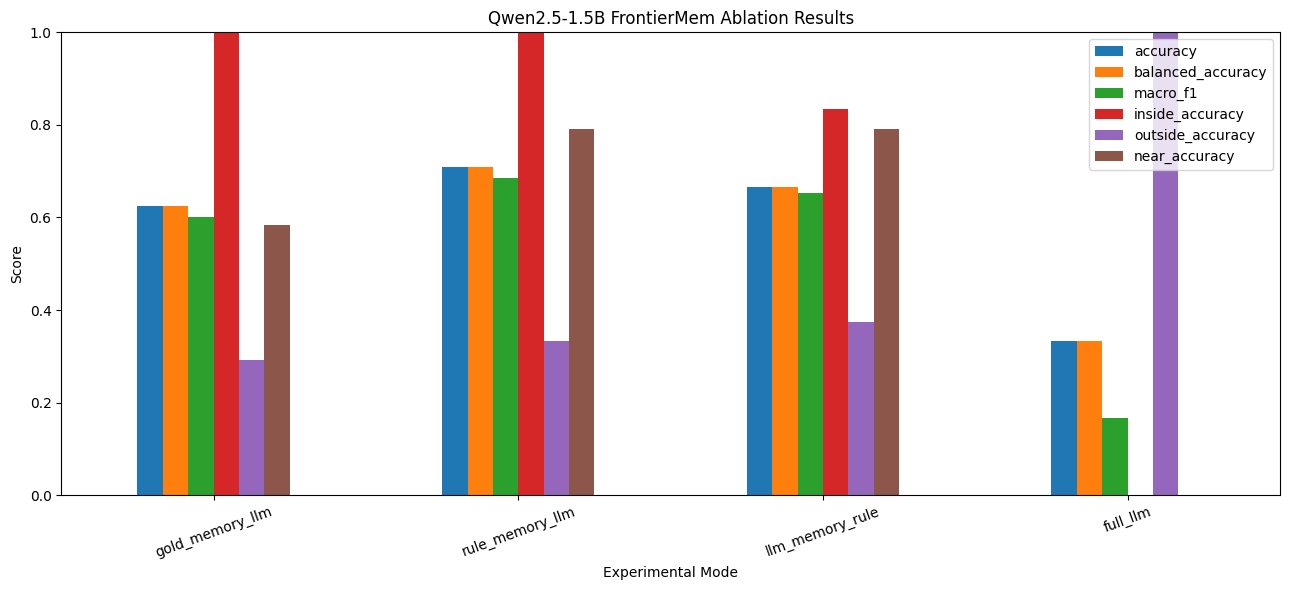

Saved: /kaggle/working/frontiermem_llm_prototype_fixed/results/qwen_1_5b_ablation_metrics.png


In [52]:
import matplotlib.pyplot as plt

plot_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "inside_accuracy",
    "outside_accuracy",
    "near_accuracy",
]

available_plot_columns = [
    col for col in plot_columns
    if col in metrics_summary.columns
]

plot_df = (
    metrics_summary
    .set_index("mode")[
        available_plot_columns
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(13, 6),
)

ax.set_title(
    "Qwen2.5-1.5B FrontierMem Ablation Results"
)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xlabel("Experimental Mode")
ax.tick_params(
    axis="x",
    rotation=20,
)

plt.tight_layout()

figure_path = (
    RESULTS_DIR
    / "qwen_1_5b_ablation_metrics.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)

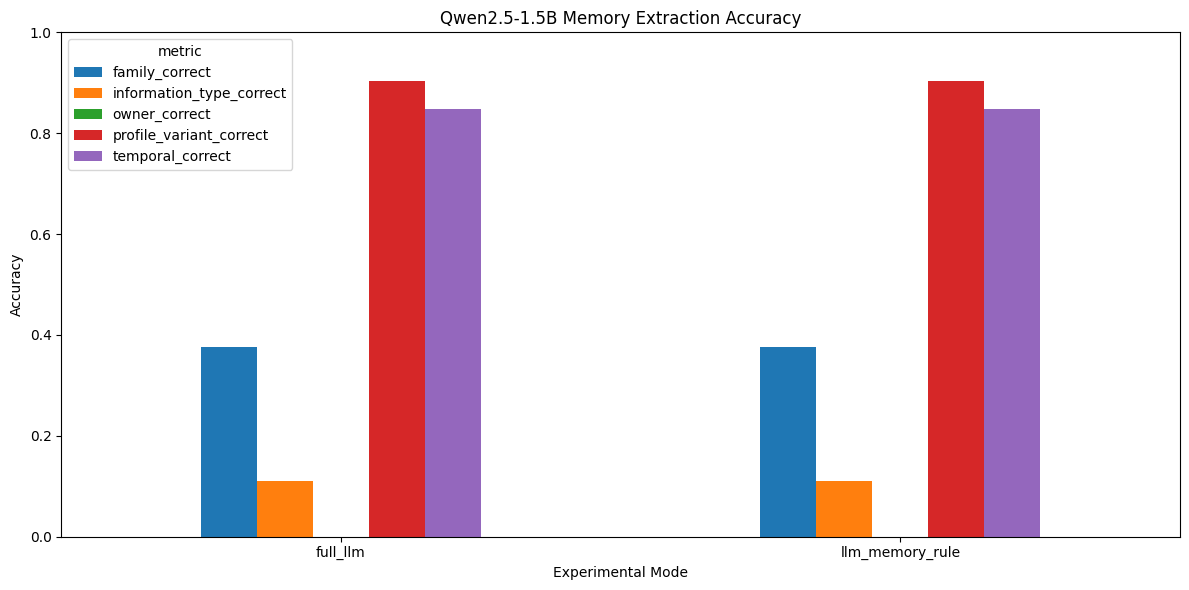

Saved: /kaggle/working/frontiermem_llm_prototype_fixed/results/qwen_1_5b_extraction_metrics.png


In [53]:
if extraction_frames:
    extraction_plot_df = (
        extraction_pivot.T
    )

    ax = extraction_plot_df.plot(
        kind="bar",
        figsize=(12, 6),
    )

    ax.set_title(
        "Qwen2.5-1.5B Memory Extraction Accuracy"
    )
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Experimental Mode")
    ax.tick_params(
        axis="x",
        rotation=0,
    )

    plt.tight_layout()

    extraction_figure_path = (
        RESULTS_DIR
        / "qwen_1_5b_extraction_metrics.png"
    )

    plt.savefig(
        extraction_figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", extraction_figure_path)

In [54]:
def get_metric(mode, metric):
    row = metrics_summary[
        metrics_summary["mode"] == mode
    ]

    if row.empty or metric not in row.columns:
        return float("nan")

    return float(row.iloc[0][metric])


def pct(value):
    if pd.isna(value):
        return "N/A"
    return f"{100 * value:.2f}%"


gold_accuracy = get_metric(
    "gold_memory_llm",
    "accuracy",
)

rule_memory_accuracy = get_metric(
    "rule_memory_llm",
    "accuracy",
)

llm_memory_accuracy = get_metric(
    "llm_memory_rule",
    "accuracy",
)

full_accuracy = get_metric(
    "full_llm",
    "accuracy",
)

full_macro_f1 = get_metric(
    "full_llm",
    "macro_f1",
)

full_twin = get_metric(
    "full_llm",
    "twin_exact_match",
)

if (
    not pd.isna(gold_accuracy)
    and not pd.isna(llm_memory_accuracy)
    and gold_accuracy
    > llm_memory_accuracy + 0.15
):
    bottleneck = (
        "The results suggest that memory extraction is "
        "the main bottleneck. The model performs substantially "
        "better when it receives gold structured memory."
    )
elif (
    not pd.isna(gold_accuracy)
    and gold_accuracy < 0.60
):
    bottleneck = (
        "The decision module remains a major bottleneck, "
        "because performance is limited even when gold memory "
        "is provided."
    )
else:
    bottleneck = (
        "The results suggest a mixed bottleneck: both memory "
        "construction and final applicability decisions "
        "contribute to the remaining errors."
    )

report = f"""# FrontierMem Qwen2.5-1.5B Experimental Report

## Setup

We evaluated Qwen2.5-1.5B-Instruct on 72 balanced FrontierMem
examples using four modular experimental settings:

1. Gold memory with LLM decision
2. Rule-extracted memory with LLM decision
3. LLM-extracted memory with rule-based decision
4. Full LLM memory and decision pipeline

## Main Results

| Mode | Accuracy |
|---|---:|
| Gold Memory + LLM Decision | {pct(gold_accuracy)} |
| Rule Memory + LLM Decision | {pct(rule_memory_accuracy)} |
| LLM Memory + Rule Policy | {pct(llm_memory_accuracy)} |
| Full LLM Pipeline | {pct(full_accuracy)} |

The full pipeline achieved a Macro-F1 of {pct(full_macro_f1)}
and a twin exact-match score of {pct(full_twin)}.

## Interpretation

{bottleneck}

Unlike the previous 0.5B zero-shot run, this modular evaluation
allows us to separate errors caused by memory extraction from
errors caused by the final APPLY, IGNORE, or CLARIFY decision.

## Important Caveat

The current dataset is controlled and synthetic. The rule-based
memory extractor is aligned with the scenario templates, so its
performance should not be interpreted as evidence of real-world
generalization.

## Next Step

The next research step is structured supervised fine-tuning on
counterfactual twin histories, followed by evaluation on more
natural and lexically diverse interaction histories.
"""

report_path = RESULTS_DIR / "RUN_REPORT.md"

report_path.write_text(
    report,
    encoding="utf-8",
)

print(report)
print("\nSaved:", report_path)

# FrontierMem Qwen2.5-1.5B Experimental Report

## Setup

We evaluated Qwen2.5-1.5B-Instruct on 72 balanced FrontierMem
examples using four modular experimental settings:

1. Gold memory with LLM decision
2. Rule-extracted memory with LLM decision
3. LLM-extracted memory with rule-based decision
4. Full LLM memory and decision pipeline

## Main Results

| Mode | Accuracy |
|---|---:|
| Gold Memory + LLM Decision | 62.50% |
| Rule Memory + LLM Decision | 70.83% |
| LLM Memory + Rule Policy | 66.67% |
| Full LLM Pipeline | 33.33% |

The full pipeline achieved a Macro-F1 of 16.67%
and a twin exact-match score of 0.00%.

## Interpretation

The results suggest a mixed bottleneck: both memory construction and final applicability decisions contribute to the remaining errors.

Unlike the previous 0.5B zero-shot run, this modular evaluation
allows us to separate errors caused by memory extraction from
errors caused by the final APPLY, IGNORE, or CLARIFY decision.

## Important Caveat

The curre

In [55]:
import shutil

EXPORT_DIR = Path(
    "/kaggle/working/"
    "FrontierMem_1_5B_Final_Results"
)

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

patterns = [
    f"metrics_{MODEL_SLUG}_*.csv",
    f"predictions_{MODEL_SLUG}_*.csv",
    f"extraction_{MODEL_SLUG}_*.csv",
    f"confusion_{MODEL_SLUG}_*.csv",
    "qwen_1_5b_*.csv",
    "qwen_1_5b_*.png",
    "full_llm_*.csv",
    "presentation_examples.csv",
    "RUN_REPORT.md",
]

copied_files = []

for pattern in patterns:
    for source_path in RESULTS_DIR.glob(pattern):
        destination = EXPORT_DIR / source_path.name

        shutil.copy2(
            source_path,
            destination,
        )

        copied_files.append(
            destination.name
        )

# کپی اسکریپت اصلی اجرا
script_path = (
    PROJECT_DIR
    / "run_qwen_fast_ablation.py"
)

if script_path.exists():
    shutil.copy2(
        script_path,
        EXPORT_DIR
        / "run_qwen_fast_ablation.py",
    )

print("Copied files:", len(copied_files))

for name in sorted(set(copied_files)):
    print("-", name)

Copied files: 28
- RUN_REPORT.md
- confusion_Qwen2_5-1_5B-Instruct_full_llm.csv
- confusion_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv
- confusion_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv
- confusion_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv
- extraction_Qwen2_5-1_5B-Instruct_full_llm.csv
- extraction_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv
- full_llm_by_domain.csv
- full_llm_by_profile_variant.csv
- full_llm_by_query_kind.csv
- full_llm_by_zone.csv
- full_llm_correct_examples.csv
- full_llm_errors.csv
- metrics_Qwen2_5-1_5B-Instruct_full_llm.csv
- metrics_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv
- metrics_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv
- metrics_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv
- predictions_Qwen2_5-1_5B-Instruct_full_llm.csv
- predictions_Qwen2_5-1_5B-Instruct_gold_memory_llm.csv
- predictions_Qwen2_5-1_5B-Instruct_llm_memory_rule.csv
- predictions_Qwen2_5-1_5B-Instruct_rule_memory_llm.csv
- presentation_examples.csv
- qwen_1_5b_ablation_metrics.png
- qwen_1_5b

In [56]:
archive_base = (
    "/kaggle/working/"
    "FrontierMem_1_5B_Final_Results"
)

zip_path = shutil.make_archive(
    archive_base,
    "zip",
    root_dir="/kaggle/working",
    base_dir="FrontierMem_1_5B_Final_Results",
)

print("Created:", zip_path)
print(
    "Size:",
    round(
        os.path.getsize(zip_path)
        / 1024
        / 1024,
        2,
    ),
    "MB",
)

Created: /kaggle/working/FrontierMem_1_5B_Final_Results.zip
Size: 0.23 MB


In [57]:
!ls -lh /kaggle/working/FrontierMem_1_5B_Final_Results.zip

-rw-r--r-- 1 root root 232K Aug  5 14:51 /kaggle/working/FrontierMem_1_5B_Final_Results.zip


In [ ]:
!python run_qwen_fast_ablation.py \
    --model Qwen/Qwen2.5-3B-Instruct \
    --mode gold_memory_llm \
    --max-examples 72

tokenizer_config.json: 7.30kB [00:00, 17.0MB/s]
vocab.json: 2.78MB [00:00, 43.7MB/s]
merges.txt: 1.67MB [00:00, 115MB/s]
tokenizer.json: 7.03MB [00:00, 154MB/s]
config.json: 100%|█████████████████████████████| 661/661 [00:00<00:00, 3.19MB/s]
model.safetensors.index.json: 35.6kB [00:00, 75.5MB/s]
Fetching 2 files:   0%|                                   | 0/2 [00:00<?, ?it/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|             | 0.00/3.97G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|  | 20.3k/3.97G [00:00<10:52:41, 101kB/s]
model-00002-of-00002.safetensors:   0%|             | 0.00/2.20G [00:00<?, ?B/s]
model-00002-of-00002.safetensors:   0%|             